# Exploratory Data Analysis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

df = pd.read_csv('clean_task_data.csv')
df

,ORGANIZATION_ID,ACTIVITY_NAME,TIMESTAMP,CONVERTED,CONVERTED_AT,TRIAL_START,TRIAL_END,DAYS_INTO_TRIAL,TRIAL_WEEK,COHORT_MONTH,TRIAL_START_MONTH,DAYS_TO_CONVERT,LATE_CONVERSION
0,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:03:53,False,NaN,2024-03-27 10:11:39,2024-04-26 10:11:39,0,1,2024-03,March,NaN,False
1,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:52,False,NaN,2024-03-27 10:11:39,2024-04-26 10:11:39,0,1,2024-03,March,NaN,False
2,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:04:53,False,NaN,2024-03-27 10:11:39,2024-04-26 10:11:39,0,1,2024-03,March,NaN,False
3,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:05:18,False,NaN,2024-03-27 10:11:39,2024-04-26 10:11:39,0,1,2024-03,March,NaN,False
4,0040dd9ab132b92d5d04bc3acf14d2e2,Scheduling.Shift.Created,2024-03-27 11:06:00,False,NaN,2024-03-27 10:11:39,2024-04-26 10:11:39,0,1,2024-03,March,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
102890,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:14:34,False,NaN,2024-01-04 12:07:40,2024-02-03 12:07:40,27,4,2024-01,January,NaN,False
102891,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:14:37,False,NaN,2024-01-04 12:07:40,2024-02-03 12:07:40,27,4,2024-01,January,NaN,False
102892,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:15:21,False,NaN,2024-01-04 12:07:40,2024-02-03 12:07:40,27,4,2024-01,January,NaN,False
102893,4eb736e6ff7851d301ae68a6aa37081a,Mobile.Schedule.Loaded,2024-01-31 22:15:26,False,NaN,2024-01-04 12:07:40,2024-02-03 12:07:40,27,4,2024-01,January,NaN,False


In [24]:
# Count distinct organizations
total_orgs = df['ORGANIZATION_ID'].nunique()

# organizations that converted
converted_orgs = df[df['CONVERTED'] == True]['ORGANIZATION_ID'].nunique()
perc_converted_orgs = (converted_orgs / total_orgs) * 100

# organizations that did NOT convert
unconverted_orgs = df[df['CONVERTED'] == False]['ORGANIZATION_ID'].nunique()
perc_unconverted_orgs = (unconverted_orgs / total_orgs) * 100

print(f"\nSummary:")
print(f"  Total Organisations: {total_orgs}")
print(f"  Converted: {converted_orgs} ({perc_converted_orgs:.2f}%)")
print(f"  Not Converted: {unconverted_orgs} ({perc_unconverted_orgs:.2f}%)")


Summary:
  Total Organisations: 966
  Converted: 206 (21.33%)
  Not Converted: 760 (78.67%)


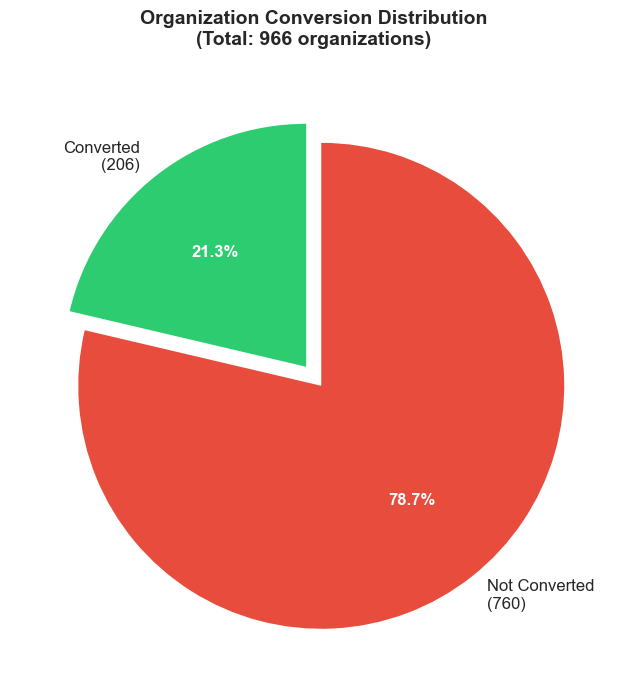

In [ ]:
# organization conversion distribution
fig, ax = plt.subplots(figsize=(10, 7))
org_distribution = [converted_orgs, unconverted_orgs]
labels = [f'Converted\n({converted_orgs})', f'Not Converted\n({unconverted_orgs})']
colors = ['#2ecc71', '#e74c3c']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax.pie(org_distribution, labels=labels, autopct='%1.1f%%', 
                                    colors=colors, explode=explode, startangle=90,
                                    textprops={'fontsize': 12})

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.set_title(f'Organization Conversion Distribution\n(Total: {total_orgs} organizations)', 
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()